In [ ]:
!jupyter nbconvert --to html /content/group_18_credit_card_defaulters_phase_2.ipynb

[NbConvertApp] Converting notebook /content/group_18_credit_card_defaulters_phase_2.ipynb to html
[NbConvertApp] Writing 725459 bytes to /content/group_18_credit_card_defaulters_phase_2.html


<h1><center><b>Credit Card Defaulters</b></center></h1>

#**Phase 2**
<ul>
  <li>Perform frequent pattern mining to identify patterns of defaulters and non-defaulters</li>
  <li>Perform outlier analysis on the data</li>
  <li>Perform cluster analysis on the data.</li>
</ul>

#**Group # 18**
<ul>
  <li> Saad Qadeer 2022-10-0209 </li>
  <li> Khawaja Junaid 2022-10-0072 </li>
  <li> Muhammad Bilal 2022-10-0224 </li>
</ul>


<b>Importing Libraries</b>

In [ ]:
%pip install mlxtend --upgrade

     |████████████████████████████████| 1.3 MB 8.9 MB/s 
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.14.0
    Uninstalling mlxtend-0.14.0:
      Successfully uninstalled mlxtend-0.14.0


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import f_oneway
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import association_rules
from scipy import stats

<b>Mouting Google Drive</b>



In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


<b>Loading dataset</b>

In [ ]:
df =pd.read_csv("/content/drive/My Drive/CS 432 - Project/Group#18/Phase 2/cleaned_data.csv")

In [ ]:
df.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,1,0,1,0,1,0,202500.0,406597.5,0,1,1,0,0,1.0,2,0.0
1,0,0,0,0,0,0,270000.0,1293502.5,3,4,0,0,2,2.0,1,6.0
2,0,1,1,1,1,0,67500.0,135000.0,0,1,1,0,0,1.0,2,5.0
3,0,0,0,0,1,0,135000.0,312682.5,0,1,2,0,0,2.0,2,0.0
4,0,0,1,0,1,0,121500.0,513000.0,0,1,1,0,2,1.0,2,51.0


#<b>Frequent Pattern Analysis</b>

In [ ]:
copy = df.copy()

In [ ]:
copy.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,1,0,1,0,1,0,202500.0,406597.5,0,1,1,0,0,1.0,2,0.0
1,0,0,0,0,0,0,270000.0,1293502.5,3,4,0,0,2,2.0,1,6.0
2,0,1,1,1,1,0,67500.0,135000.0,0,1,1,0,0,1.0,2,5.0
3,0,0,0,0,1,0,135000.0,312682.5,0,1,2,0,0,2.0,2,0.0
4,0,0,1,0,1,0,121500.0,513000.0,0,1,1,0,2,1.0,2,51.0


##<b>Feature Selection and Feature Engineering</b>

From the results of phase 1, we see that not all the variables have a strong co-relation with the target variable. The strenght of the relation can be termed as strong, weak or non-existent. To deal with variables that have a weak or no correlation with the target variable, we can drop some of the columns that we deem do not have any impact on the target variable based on our findings from the Exploratory Data Analysis of the dataset.<br><b>However</b>, since we are looking for frequent patterns in the dataset, we might eventually up loosing meaningful data, because there is a possibility that although attributes may apprarently not be related to the target variable, some of those attributes may be working <b>together</b> to have some kind of relation with the target variable.

##<b>Preparing the data set to Run the Frequent Pattern Analysis Algorithm</b>

###<b>Dropping Numerical Columns</b>



For us to run frequent pattern analysis algorithms such as FP Growht and Apriori we need to drop the Continuous Numerical variables as they can not form a part of the frequent item sets.<br>

From our dataset, the attributes that were Numerical-Continuous were <b>INCOME_TOTAL</b> and <b>CREDIT</b>.
We can choose to drop the numerical columns using the code below:<br>
>
>copy.drop(['INCOME_TOTAL', 'CREDIT'], axis=1, inplace=True)<br>
>
Another approach would be to encode them, as dicussed below.

##<b>Encoding</b>

###<b>Encoding the Numerical Variables</b>

We have two columns in our data that are of the type Numerical-Continuous Variables. To feed these columns into the data we need to encode them. Encoding all the values of a continouous variable is nearly impossible. A solution to this conundrum can be to use a central tendency value such as the mean of the attribute, i.e. assign 0 to the values that are below the mean amount and assign 1 to the values that are greater than the mean amount.

<b>Encoding INCOME_TOTAL attribute</b>

In [ ]:
meanIncomeTotal = copy['INCOME_TOTAL'].mean()
copy['INCOME_TOTAL'] = copy['INCOME_TOTAL'].apply(lambda x: 0 if x < meanIncomeTotal else 1)

<b>Encoding CREDIT attribute</b>

In [ ]:
meanCredit = copy['CREDIT'].mean()
copy['CREDIT'] = copy['CREDIT'].apply(lambda x: 0 if x < meanCredit else 1)

In [ ]:
copy.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,1,0,1,0,1,0,1,0,0,1,1,0,0,1.0,2,0.0
1,0,0,0,0,0,0,1,1,3,4,0,0,2,2.0,1,6.0
2,0,1,1,1,1,0,0,0,0,1,1,0,0,1.0,2,5.0
3,0,0,0,0,1,0,0,0,0,1,2,0,0,2.0,2,0.0
4,0,0,1,0,1,0,0,0,0,1,1,0,2,1.0,2,51.0


###<b>One Hot Encoding</b>

For the dataset to be run through the FPA algorithms, we need to encode the data. For encoding we are using One-Hot-Encoding. <br> https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore')

In [ ]:
encode = pd.DataFrame(encoder.fit_transform(copy).toarray())

Running the encoder assigns numerical labels to the data frame. To retain the string column names we use the following function.

In [ ]:
encode.columns = encoder.get_feature_names_out()

In [ ]:
encode.head()

,TARGET_0,TARGET_1,NAME_CONTRACT_TYPE_0,NAME_CONTRACT_TYPE_1,CODE_GENDER_0,CODE_GENDER_1,FLAG_OWN_CAR_0,FLAG_OWN_CAR_1,FLAG_OWN_REALTY_0,FLAG_OWN_REALTY_1,...,ORGANIZATION_TYPE_46.0,ORGANIZATION_TYPE_47.0,ORGANIZATION_TYPE_48.0,ORGANIZATION_TYPE_49.0,ORGANIZATION_TYPE_50.0,ORGANIZATION_TYPE_51.0,ORGANIZATION_TYPE_52.0,ORGANIZATION_TYPE_53.0,ORGANIZATION_TYPE_54.0,ORGANIZATION_TYPE_55.0
0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


####<b>Type Casting</b>

Running the encode has cause all the value to be converted to float. For consistency we will convert them back to integers using the below code.

In [ ]:
for i in encode.columns:
  encode[i] = encode[i].apply(lambda x: int(x))

In [ ]:
encode.shape

(291858, 147)

In [ ]:
encode.head()

,TARGET_0,TARGET_1,NAME_CONTRACT_TYPE_0,NAME_CONTRACT_TYPE_1,CODE_GENDER_0,CODE_GENDER_1,FLAG_OWN_CAR_0,FLAG_OWN_CAR_1,FLAG_OWN_REALTY_0,FLAG_OWN_REALTY_1,...,ORGANIZATION_TYPE_46.0,ORGANIZATION_TYPE_47.0,ORGANIZATION_TYPE_48.0,ORGANIZATION_TYPE_49.0,ORGANIZATION_TYPE_50.0,ORGANIZATION_TYPE_51.0,ORGANIZATION_TYPE_52.0,ORGANIZATION_TYPE_53.0,ORGANIZATION_TYPE_54.0,ORGANIZATION_TYPE_55.0
0,0,1,1,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,1,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,0,1,0,0,1,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0


#<b>FPA for Defaulters Dataset</b>

###<b>Choice of Algorithm</b>

For conducting the frequent pattern analysis we chose to run the FP Growth algorithm as it is faster and more efficient as compared to other algorithms.

###<b>FP Growth Implementation</b>

####<b>Frequent Patterns for Defaulters</b>

In [ ]:
defaulters_df = encode[encode['TARGET_1']==1]
defaulters_df.head()

,TARGET_0,TARGET_1,NAME_CONTRACT_TYPE_0,NAME_CONTRACT_TYPE_1,CODE_GENDER_0,CODE_GENDER_1,FLAG_OWN_CAR_0,FLAG_OWN_CAR_1,FLAG_OWN_REALTY_0,FLAG_OWN_REALTY_1,...,ORGANIZATION_TYPE_46.0,ORGANIZATION_TYPE_47.0,ORGANIZATION_TYPE_48.0,ORGANIZATION_TYPE_49.0,ORGANIZATION_TYPE_50.0,ORGANIZATION_TYPE_51.0,ORGANIZATION_TYPE_52.0,ORGANIZATION_TYPE_53.0,ORGANIZATION_TYPE_54.0,ORGANIZATION_TYPE_55.0
0,0,1,1,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
26,0,1,1,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
38,0,1,1,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
40,0,1,1,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
78,0,1,1,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
fpGrowth_defaulters = fpgrowth(defaulters_df, min_support = 0.2, use_colnames=True)

<b>Appending the Length column</b>

In [ ]:
fpGrowth_defaulters['Length'] = fpGrowth_defaulters['itemsets'].apply(lambda x: len(x))

In [ ]:
fpGrowth_defaulters.sample(15)

,support,itemsets,Length
780,0.352977,"(OCCUPATION_TYPE_0, REGION_RATING_CLIENT_2)",2
2843,0.218133,"(EDUCATION_TYPE_1, FAM_MEMBERS_2.0, CODE_GENDE...",3
1563,0.271876,"(CREDIT_0, NAME_CONTRACT_TYPE_0, FLAG_OWN_CAR_...",5
183,0.449195,"(CNT_CHILDREN_0, NAME_CONTRACT_TYPE_0, TARGET_...",4
2386,0.207839,"(CREDIT_0, FAMILY_STATUS_0, FLAG_OWN_REALTY_1,...",5
2346,0.266242,"(CREDIT_0, REGION_RATING_CLIENT_2, FAMILY_STAT...",3
309,0.323187,"(CREDIT_0, HOUSING_TYPE_0, EDUCATION_TYPE_1, F...",4
2583,0.314149,"(NAME_CONTRACT_TYPE_0, TARGET_1, FAM_MEMBERS_2...",4
1726,0.319296,"(TARGET_1, FLAG_OWN_REALTY_1, FLAG_OWN_CAR_0, ...",4
2422,0.252138,"(TARGET_1, FAMILY_STATUS_0, NAME_INCOME_TYPE_0...",4


In [ ]:
maxLengthDefaulters  = fpGrowth_defaulters['Length'].max()
print('The maximum length of a frequent itemset from FP Growth is: ', maxLengthDefaulters)

The maximum length of a frequent itemset from FP Growth is:  7


#####<b>Frequent Item Sets of Maximum Lenght</b>

The following data frame shows the most frequent itemsets that were of the the maximum length, 7, that were found as a result of the running the FP Growth Algorithm.

In [ ]:
itemSetsofMaxLength = fpGrowth_defaulters[fpGrowth_defaulters['Length']==7]
itemSetsofMaxLength

,support,itemsets,Length
144,0.236737,"(FLAG_OWN_REALTY_1, REGION_RATING_CLIENT_2, NA...",7
208,0.227820,"(CNT_CHILDREN_0, REGION_RATING_CLIENT_2, NAME_...",7
240,0.230049,"(CNT_CHILDREN_0, FLAG_OWN_REALTY_1, REGION_RAT...",7
256,0.224496,"(CNT_CHILDREN_0, FLAG_OWN_REALTY_1, NAME_CONTR...",7
263,0.200097,"(CNT_CHILDREN_0, FLAG_OWN_REALTY_1, REGION_RAT...",7
328,0.216512,"(CREDIT_0, REGION_RATING_CLIENT_2, NAME_CONTRA...",7
360,0.220484,"(CREDIT_0, FLAG_OWN_REALTY_1, REGION_RATING_CL...",7
376,0.213472,"(CREDIT_0, FLAG_OWN_REALTY_1, NAME_CONTRACT_TY...",7
414,0.202975,"(CREDIT_0, CNT_CHILDREN_0, NAME_CONTRACT_TYPE_...",7
430,0.203502,"(CREDIT_0, CNT_CHILDREN_0, REGION_RATING_CLIEN...",7


####<b>Frequent Patterns for Non-Defaulters</b>

In [ ]:
nondefaulters_df = encode[encode['TARGET_0']==1]
nondefaulters_df.head()

,TARGET_0,TARGET_1,NAME_CONTRACT_TYPE_0,NAME_CONTRACT_TYPE_1,CODE_GENDER_0,CODE_GENDER_1,FLAG_OWN_CAR_0,FLAG_OWN_CAR_1,FLAG_OWN_REALTY_0,FLAG_OWN_REALTY_1,...,ORGANIZATION_TYPE_46.0,ORGANIZATION_TYPE_47.0,ORGANIZATION_TYPE_48.0,ORGANIZATION_TYPE_49.0,ORGANIZATION_TYPE_50.0,ORGANIZATION_TYPE_51.0,ORGANIZATION_TYPE_52.0,ORGANIZATION_TYPE_53.0,ORGANIZATION_TYPE_54.0,ORGANIZATION_TYPE_55.0
1,1,0,1,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,1,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,0,1,0,0,1,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
5,1,0,1,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
fpGrowth_nondefaulters = fpgrowth(nondefaulters_df, min_support = 0.2, use_colnames=True)

<b>Appending the Length column</b>

In [ ]:
fpGrowth_nondefaulters['Length'] = fpGrowth_nondefaulters['itemsets'].apply(lambda x: len(x))

In [ ]:
fpGrowth_nondefaulters.sample(15)

,support,itemsets,Length
790,0.253150,"(CNT_CHILDREN_0, FAMILY_STATUS_0, REGION_RATIN...",7
2564,0.218613,"(FAMILY_STATUS_0, CODE_GENDER_1, TARGET_0, HOU...",4
610,0.370212,"(CNT_CHILDREN_0, FAMILY_STATUS_0, NAME_CONTRAC...",5
120,0.223594,"(CNT_CHILDREN_0, FLAG_OWN_REALTY_1, CODE_GENDE...",6
1612,0.200719,"(CNT_CHILDREN_0, FAMILY_STATUS_0, NAME_CONTRAC...",6
1802,0.260759,"(CREDIT_0, HOUSING_TYPE_0, REGION_RATING_CLIEN...",4
934,0.233550,"(TARGET_0, EDUCATION_TYPE_1, INCOME_TOTAL_0, F...",4
1325,0.203612,"(CNT_CHILDREN_0, REGION_RATING_CLIENT_2, NAME_...",7
117,0.236495,"(CNT_CHILDREN_0, FLAG_OWN_REALTY_1, REGION_RAT...",5
2223,0.220031,"(HOUSING_TYPE_0, FAMILY_STATUS_0, NAME_INCOME_...",4


In [ ]:
maxLengthNondefaulters  = fpGrowth_nondefaulters['Length'].max()
print('The maximum length of a frequent itemset from FP Growth is: ', maxLengthNondefaulters)

The maximum length of a frequent itemset from FP Growth is:  7


In [ ]:
itemSetofMaxLengthND = fpGrowth_nondefaulters[fpGrowth_nondefaulters['Length'] == maxLengthNondefaulters]
itemSetofMaxLengthND

,support,itemsets,Length
123,0.203294,"(CNT_CHILDREN_0, FLAG_OWN_REALTY_1, REGION_RAT...",7
155,0.204042,"(CNT_CHILDREN_0, REGION_RATING_CLIENT_2, NAME_...",7
171,0.203758,"(FLAG_OWN_REALTY_1, REGION_RATING_CLIENT_2, NA...",7
226,0.219668,"(CNT_CHILDREN_0, HOUSING_TYPE_0, REGION_RATING...",7
273,0.218523,"(HOUSING_TYPE_0, REGION_RATING_CLIENT_2, NAME_...",7
289,0.219803,"(CNT_CHILDREN_0, HOUSING_TYPE_0, NAME_CONTRACT...",7
296,0.208867,"(CNT_CHILDREN_0, REGION_RATING_CLIENT_2, NAME_...",7
329,0.214896,"(HOUSING_TYPE_0, FLAG_OWN_REALTY_1, REGION_RAT...",7
345,0.214293,"(HOUSING_TYPE_0, FLAG_OWN_REALTY_1, NAME_CONTR...",7
352,0.203148,"(FLAG_OWN_REALTY_1, REGION_RATING_CLIENT_2, NA...",7


####<b>Association Rules for FP Growth</b>

#####**Association Rules for Defaulters**

In [ ]:
association_rules(fpGrowth_defaulters, metric="confidence", min_threshold=0.7)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(NAME_CONTRACT_TYPE_0),(TARGET_1),0.935395,1.000000,0.935395,1.000000,1.00000,0.000000,inf
1,(TARGET_1),(NAME_CONTRACT_TYPE_0),1.000000,0.935395,0.935395,0.935395,1.00000,0.000000,1.000000
2,(TARGET_1),(HOUSING_TYPE_0),1.000000,0.855996,0.855996,0.855996,1.00000,0.000000,1.000000
3,(HOUSING_TYPE_0),(TARGET_1),0.855996,1.000000,0.855996,1.000000,1.00000,0.000000,inf
4,(NAME_CONTRACT_TYPE_0),(HOUSING_TYPE_0),0.935395,0.855996,0.802456,0.857879,1.00220,0.001761,1.013249
...,...,...,...,...,...,...,...,...,...
13969,(CNT_CHILDREN_1),(TARGET_1),0.220808,1.000000,0.220808,1.000000,1.00000,0.000000,inf
13970,(CNT_CHILDREN_1),(NAME_CONTRACT_TYPE_0),0.220808,0.935395,0.204434,0.925844,0.98979,-0.002109,0.871208
13971,"(CNT_CHILDREN_1, NAME_CONTRACT_TYPE_0)",(TARGET_1),0.204434,1.000000,0.204434,1.000000,1.00000,0.000000,inf
13972,"(CNT_CHILDREN_1, TARGET_1)",(NAME_CONTRACT_TYPE_0),0.220808,0.935395,0.204434,0.925844,0.98979,-0.002109,0.871208


#####**Association Rules for Non-Defaulters**

In [ ]:
association_rules(fpGrowth_nondefaulters, metric="confidence", min_threshold=0.7)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(NAME_CONTRACT_TYPE_0),(TARGET_0),0.903939,1.000000,0.903939,1.000000,1.000000,0.000000,inf
1,(TARGET_0),(NAME_CONTRACT_TYPE_0),1.000000,0.903939,0.903939,0.903939,1.000000,0.000000,1.000000
2,(TARGET_0),(HOUSING_TYPE_0),1.000000,0.883972,0.883972,0.883972,1.000000,0.000000,1.000000
3,(HOUSING_TYPE_0),(TARGET_0),0.883972,1.000000,0.883972,1.000000,1.000000,0.000000,inf
4,(NAME_CONTRACT_TYPE_0),(HOUSING_TYPE_0),0.903939,0.883972,0.801026,0.886150,1.002464,0.001969,1.019130
...,...,...,...,...,...,...,...,...,...
12449,(NAME_INCOME_TYPE_1),"(NAME_CONTRACT_TYPE_0, TARGET_0)",0.246043,0.903939,0.218085,0.886369,0.980562,-0.004323,0.845373
12450,"(NAME_INCOME_TYPE_1, TARGET_0)",(HOUSING_TYPE_0),0.246043,0.883972,0.215873,0.877379,0.992542,-0.001622,0.946232
12451,"(NAME_INCOME_TYPE_1, HOUSING_TYPE_0)",(TARGET_0),0.215873,1.000000,0.215873,1.000000,1.000000,0.000000,inf
12452,(NAME_INCOME_TYPE_1),"(TARGET_0, HOUSING_TYPE_0)",0.246043,0.883972,0.215873,0.877379,0.992542,-0.001622,0.946232


####**Interpreting the Results**

<b>Anticedents and Consequents</b><br>
>An association rule has two parts:<br>
>
>**1. an antecedent (if)<br>**
>**2. a consequent (then)<br>**
>
>An antecedent is an item found within the data. A consequent is an item found in combination with the antecedent.

1.   The **support** tells us the number of times that items co-occur with each other
2.   The **confidece** indicates the number of times that a rule occurs
3.   The **lift** tells us about the strength of that association



Based on the above stated metrics we can choose which rules to keep and which rules to discard. The rules can then be used to analyse what features were more prevalent in the people who were found to be defaulters and based on this data we can classify data as defaulter/non-defaulter. Other metrics such as support and confidence can also be used to test the strenght of these associations.

#<b>Cluster Analysis</b>

In [ ]:
my_df =pd.read_csv("/content/drive/My Drive/CS 432 - Project/Group#18/Phase 2/cleaned_data.csv")

In [ ]:
my_df
del my_df[]

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,1,0,1,0,1,0,202500.0,406597.5,0,1,1,0,0,1.0,2,0.0
1,0,0,0,0,0,0,270000.0,1293502.5,3,4,0,0,2,2.0,1,6.0
2,0,1,1,1,1,0,67500.0,135000.0,0,1,1,0,0,1.0,2,5.0
3,0,0,0,0,1,0,135000.0,312682.5,0,1,2,0,0,2.0,2,0.0
4,0,0,1,0,1,0,121500.0,513000.0,0,1,1,0,2,1.0,2,51.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291853,0,0,0,0,1,0,153000.0,450000.0,0,1,3,0,1,1.0,2,1.0
291854,0,0,1,0,0,0,157500.0,254700.0,0,1,3,1,1,1.0,1,27.0
291855,0,0,0,0,1,0,153000.0,677664.0,0,4,3,0,3,1.0,3,6.0
291856,1,0,0,0,1,0,171000.0,370107.0,1,1,0,0,0,2.0,2,10.0


<b>Extracting n-dimensional datavalues from dataframe.</b>

In [ ]:
X = my_df.iloc[:,0:].values
X

array([[ 1.,  0.,  1., ...,  1.,  2.,  0.],
       [ 1.,  0.,  0., ...,  1.,  3.,  0.],
       [ 1.,  0.,  1., ...,  2.,  2.,  0.],
       ...,
       [ 1.,  0.,  1., ...,  2.,  2.,  0.],
       [ 1.,  0.,  0., ...,  2.,  2.,  0.],
       [ 1.,  0.,  0., ...,  2.,  2., 10.]])

####<b>The Elbow Method</b>

The elbow method is a heuristic used in determining the number of clusters in a data set. We will use this technique to identify the optimal number of clusters for our cluster analysis.

In [ ]:
wcss =[]
for i in range (1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

Plotting the graph to visualize the Elbow Method to find the optimal number of cluster.  

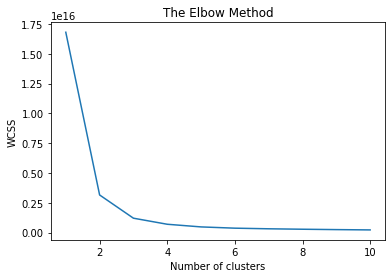

In [ ]:
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Intialized n_clusters=4, as optimal value came out to be 4.

In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++')

#used normalizer to normalize datavalues
normalizer = Normalizer()
pipeline = make_pipeline(normalizer,kmeans)

pipeline.fit(X)

#assigned cluster to each datavalue
clusters = pipeline.predict(X)

<b>Data Values that belong to cluster 0</b>

In [ ]:
points = np.array([X[j] for j in range(len(X)) if clusters[j] == 0])
df = pd. DataFrame(points, columns=my_df.columns)

In [ ]:
pd.DataFrame(df['TARGET'].value_counts())

,TARGET
1.0,8496


In [ ]:
default=df[df['TARGET'] ==1]

In [ ]:
default['HOUSING_TYPE'].value_counts()

0.0    3235
1.0     329
2.0     153
3.0     103
4.0      19
5.0      17
Name: HOUSING_TYPE, dtype: int64

<b>Data Values that belong to cluster 1</b>

In [ ]:
points1 = np.array([X[j] for j in range(len(X)) if clusters[j] == 1])
df1 = pd. DataFrame(points1, columns=my_df.columns)

In [ ]:
pd.DataFrame(df1['TARGET'].value_counts())

,TARGET
1.0,1531


In [ ]:
default1= df1[df1['TARGET'] ==1]

In [ ]:
default1['HOUSING_TYPE'].value_counts()

0.0    1292
1.0     115
2.0      64
3.0      47
5.0       7
4.0       6
Name: HOUSING_TYPE, dtype: int64

In [ ]:
default1['CREDIT'].value_counts()

180000.0    126
225000.0     84
135000.0     83
254700.0     46
101880.0     31
           ... 
108000.0      1
278460.0      1
385375.5      1
258709.5      1
331920.0      1
Name: CREDIT, Length: 416, dtype: int64

<b>Data Values that belong to cluster 2</b>

In [ ]:
points2 = np.array([X[j] for j in range(len(X)) if clusters[j] == 2])
df2 = pd. DataFrame(points2, columns=my_df.columns)

In [ ]:
pd.DataFrame(df2['TARGET'].value_counts())

,TARGET
1.0,10236


In [ ]:
df2[df2['TARGET'] ==1]

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,1.0,0.0,0.0,0.0,1.0,0.0,112500.0,979992.0,0.0,1.0,4.0,0.0,9.0,1.0,3.0,0.0
1,1.0,0.0,1.0,0.0,1.0,0.0,202500.0,1193580.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0
2,1.0,0.0,0.0,0.0,1.0,1.0,157500.0,723996.0,1.0,3.0,3.0,0.0,1.0,2.0,2.0,25.0
3,1.0,0.0,0.0,0.0,1.0,0.0,157500.0,1710000.0,0.0,1.0,0.0,0.0,7.0,2.0,2.0,2.0
4,1.0,0.0,1.0,1.0,0.0,1.0,225000.0,1019205.0,1.0,1.0,1.0,0.0,0.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10231,1.0,0.0,0.0,0.0,1.0,0.0,58500.0,448056.0,1.0,1.0,3.0,0.0,8.0,1.0,3.0,6.0
10232,1.0,0.0,0.0,1.0,1.0,0.0,29250.0,663093.0,2.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0
10233,1.0,0.0,1.0,0.0,1.0,0.0,67500.0,313438.5,0.0,1.0,1.0,0.0,0.0,1.0,2.0,10.0
10234,1.0,0.0,1.0,0.0,1.0,0.0,135000.0,1436850.0,3.0,3.0,1.0,0.0,2.0,1.0,1.0,2.0


<b>Data Values that belong to cluster 3</b>

In [ ]:
points3 = np.array([X[j] for j in range(len(X)) if clusters[j] == 3])
df3 = pd. DataFrame(points3, columns=my_df.columns)

In [ ]:
df3[df3['TARGET'] ==1]

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,INCOME_TOTAL,CREDIT,NAME_INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,OCCUPATION_TYPE,FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,1.0,0.0,1.0,0.0,1.0,0.0,202500.0,406597.5,0.0,1.0,1.0,0.0,0.0,1.0,2.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,157500.0,245619.0,0.0,1.0,1.0,0.0,11.0,1.0,2.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,111915.0,225000.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,12.0
3,1.0,1.0,0.0,1.0,1.0,0.0,73341.0,135000.0,1.0,4.0,1.0,0.0,3.0,1.0,2.0,35.0
4,1.0,0.0,0.0,0.0,1.0,0.0,202500.0,343683.0,2.0,1.0,3.0,0.0,0.0,1.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,1.0,1.0,0.0,0.0,1.0,0.0,90000.0,135000.0,1.0,1.0,0.0,0.0,0.0,2.0,3.0,10.0
4406,1.0,0.0,1.0,0.0,0.0,0.0,135000.0,260640.0,1.0,1.0,0.0,0.0,8.0,2.0,2.0,28.0
4407,1.0,0.0,0.0,0.0,1.0,0.0,180000.0,328405.5,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0
4408,1.0,0.0,0.0,0.0,1.0,0.0,135000.0,221832.0,2.0,1.0,4.0,0.0,0.0,1.0,2.0,0.0


###<b>Comments on the Results of Cluster Analysis</b>

As we know that, using k mean clustering we try to cluster similar kinds of observations. So, from above observation we can see that how datavalues are spread over different 4 clusters. Also, we can observe that most of values belongs to cluster 1 in our case. And the people that belongs to cluster 1 are mostly non- defaulters(0).

#<b>Outlier Analysis</b>

In [ ]:
outlierDf =pd.read_csv("/content/drive/My Drive/CS 432 - Project/Group#18/Phase 2/cleaned_data.csv")

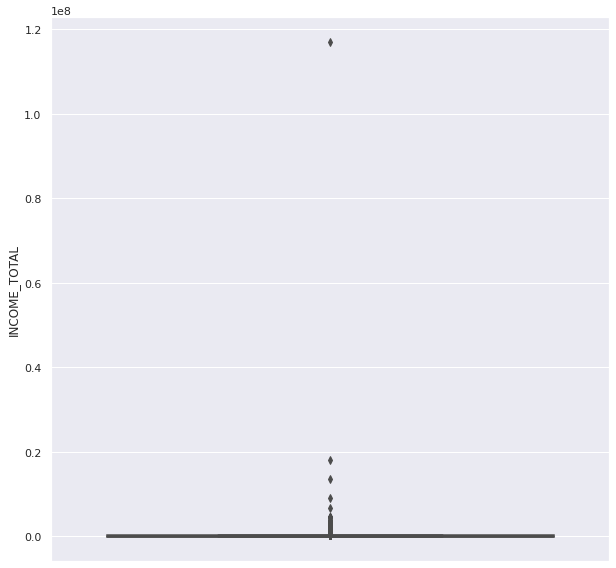

In [ ]:
ax = sns.boxplot(y='INCOME_TOTAL', data=outlierDf, linewidth=2.5,showfliers=True)
ax = sns.set(rc={'figure.figsize':(10,10)})

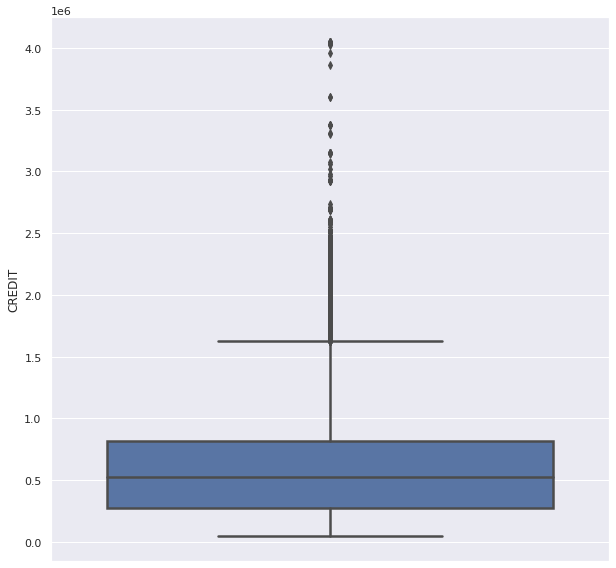

In [ ]:
ax = sns.boxplot(y='CREDIT', data=outlierDf, linewidth=2.5,showfliers=True)
ax = sns.set(rc={'figure.figsize':(10,10)})

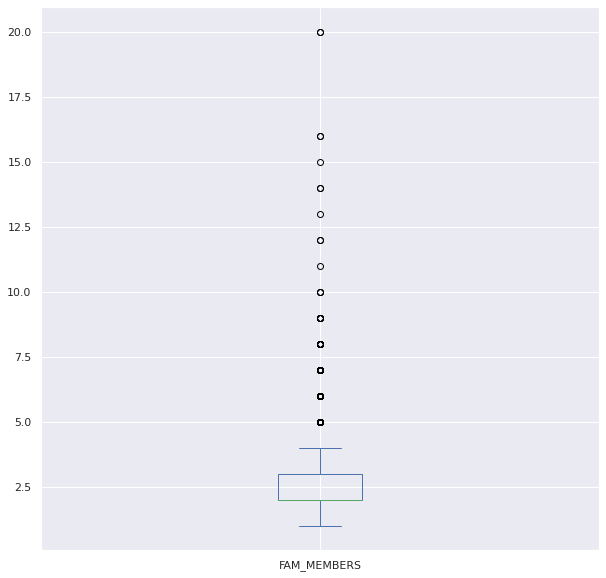

In [ ]:
fig=plt.figure(1, figsize=(10,10))
outlierDf['FAM_MEMBERS'].plot(kind='box')

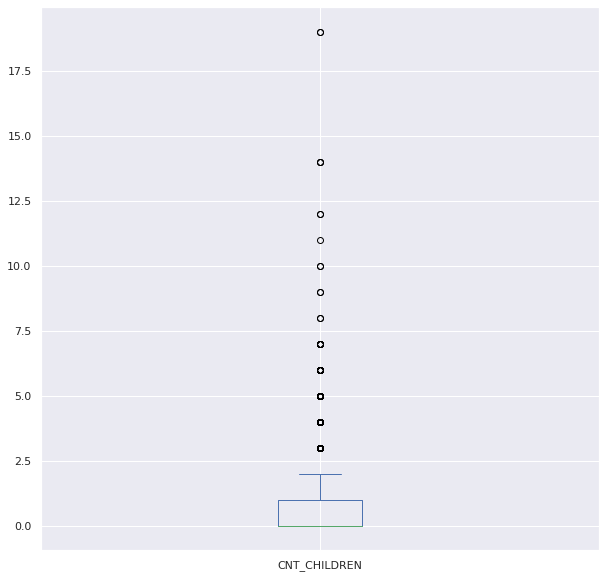

In [ ]:
outlierDf['CNT_CHILDREN'].plot(kind='box')

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


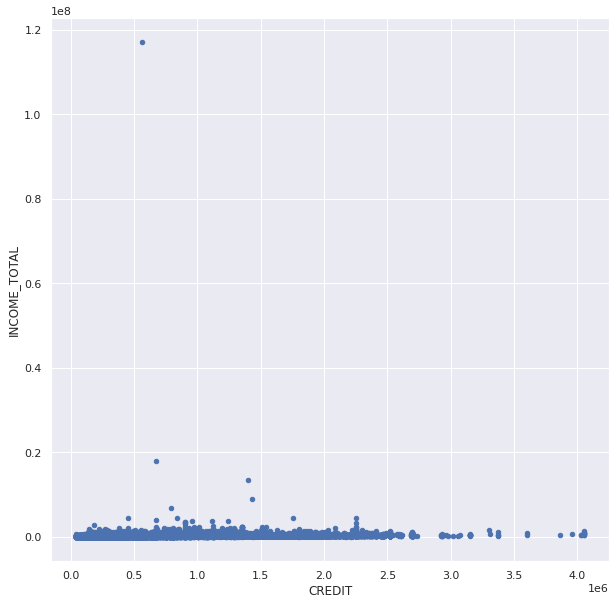

In [ ]:
outlierDf.plot.scatter(x='CREDIT', y='INCOME_TOTAL')

###**Dropping Outliers**


The z-score tells you how many standard deviations away from the mean a certain point is. Using |z-score| > 3 is a very common way to identify outliers. So for the purpose of dropping of dropping outliers we will be using the Z-score threshold value of 3.

In [ ]:
drop = outlierDf.copy()
drop.shape

(291858, 16)

In [ ]:
drop = drop[(np.abs(stats.zscore(drop['INCOME_TOTAL'])) < 3)]
drop.shape

(291408, 16)

In [ ]:
drop = drop[(np.abs(stats.zscore(drop['CREDIT'])) < 3)]
drop.shape

(288297, 16)

In [ ]:
drop = drop[(np.abs(stats.zscore(drop['FAM_MEMBERS'])) < 3)]
drop.shape

(284359, 16)

In [ ]:
drop = drop[(np.abs(stats.zscore(drop['CNT_CHILDREN'])) < 3)]
drop.shape

(284096, 16)

####**Plots after dropping outliers**

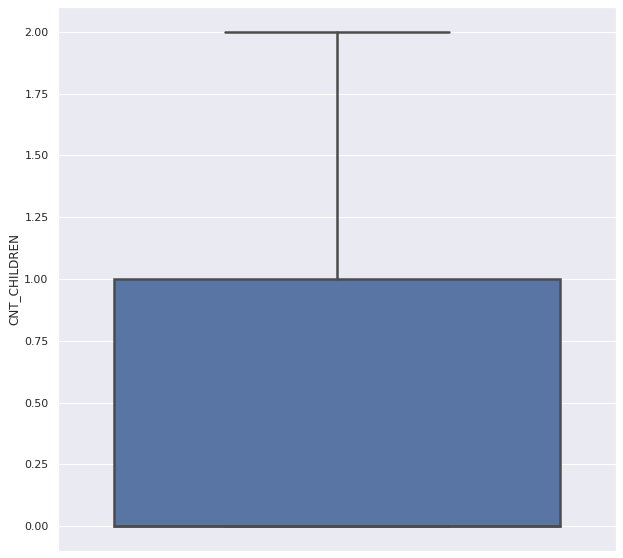

In [ ]:
ax = sns.boxplot(y='CNT_CHILDREN', data=drop, linewidth=2.5,showfliers=False)
ax = sns.set(rc={'figure.figsize':(10,10)})

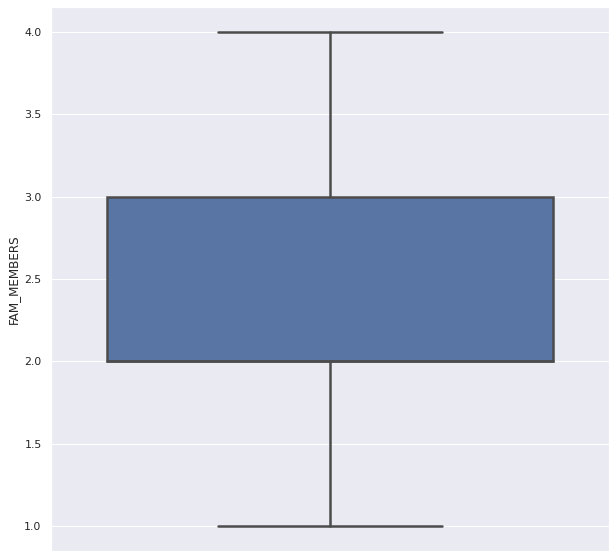

In [ ]:
ax = sns.boxplot(y='FAM_MEMBERS', data=drop, linewidth=2.5,showfliers=True)
ax = sns.set(rc={'figure.figsize':(10,10)})

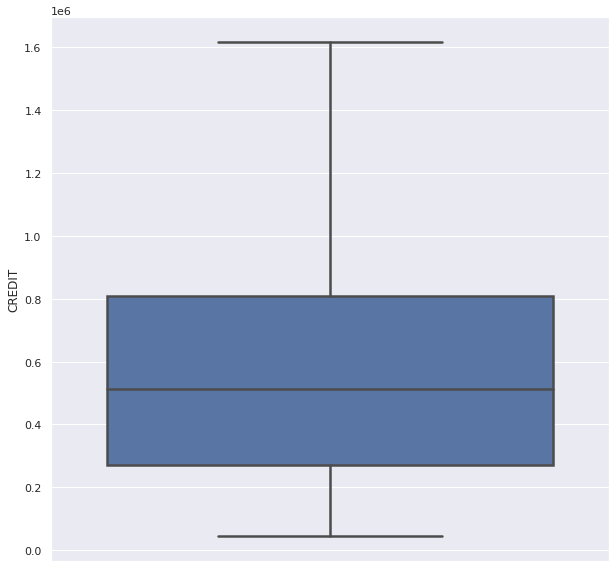

In [ ]:
ax = sns.boxplot(y='CREDIT', data=drop, linewidth=2.5,showfliers=False)
ax = sns.set(rc={'figure.figsize':(10,10)})

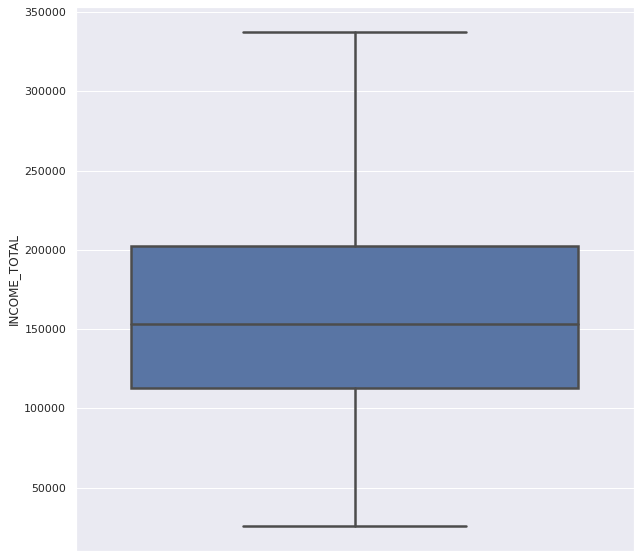

In [ ]:
ax = sns.boxplot(y='INCOME_TOTAL', data=drop, linewidth=2.5,showfliers=False)
ax = sns.set(rc={'figure.figsize':(10,10)})

As seen by the results below, the outliers that occured in the previous scatter plot are not apearing anymore and have been successfully removed.

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


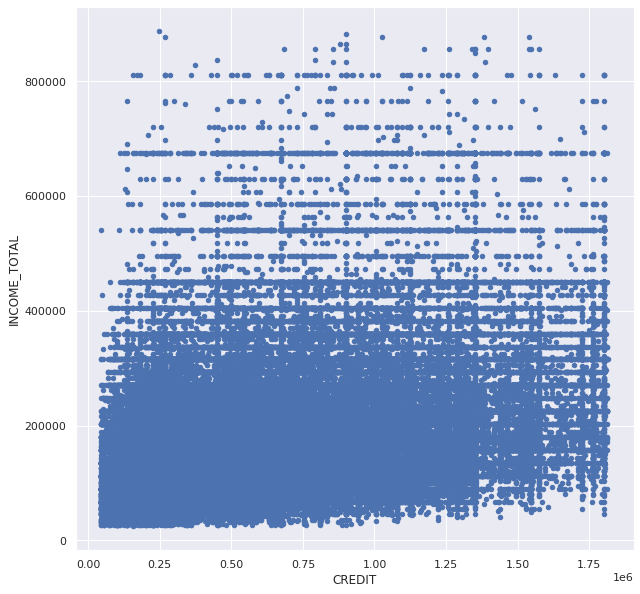

In [ ]:
drop.plot.scatter(x='CREDIT', y='INCOME_TOTAL')

###**Interpretation of the Results of Outlier Analysis**

> Outliers may cause a decrease in normality of the data, because they are **not** normally distributed. They can also cause bias in estimates and reduce the power of statistical testing and classification/prediction power of the algorithm. They may cause strong associations to appear in the frequent pattern analysis phase. <br>Outliers may come from a wrong data entry. They may also occur naturally in the data set, for example, an Income that is very very large than rest of the data is basically there because the client may be doing multiple jobs to earn extra money or may be running a high return business, not because of wrong data entry. In such a case, the outlier should not be dropped as it is providing relevant information about the data set. That may be important during analysis of the results.

We can see from the graphs above, that the number of outliers present in the data is significantly low, compared to the overall size of the data, i.e. **2,91,858**. For such a large size, the outliers might have little impact on the statistics of the data, nevertheless they will still disrupt the normality of the data. <br>

From the visualizations above: there are outliers present in the FAM_MEMBERS and CNT_CHILDREN variables. It is also important to note that both the variables are positively correlated with each other, as was suggested by our correlation analysis. A large number of children translates to a greater family size, hence greater number of family members.

><b>Total Number of Attributes = </b>16<br>
<b>Number of Catagorical Attributes =</b> 4 <br>
<b>Number of Numberical Attributes =</b> 12<br>

####**Outlier analysis on catagorical variables**

75 % of the attributes are discrete catagorical in nature. For the catagorical variables, it is not possible to perform an outlier analysis, neither does it make any sense. For example, lets take a look at the GENDER attribute, which has the values [male, female] that were later mapped to [0,1]. A data point can either exists as an instance of male or female, there can be no instances of any value in this set that can be considered to be different to the rest of the data sets. Making a plot of catagorical variables will give us distinct regions and **all** the points of the data will lie **within** this region. Hence the outlier analysis phase does not apply to such attributes.

In [ ]:
#@title
%%html
<marquee style='width: 30%; color: blue;'><b>End of Phase 2!</b></marquee>